# Exploratory Data Analysis — Last.fm Scrobbles
### Fairness & Diversity Perspective

This notebook performs a structured EDA on a Last.fm listening-history (scrobble) export,
mirroring the analysis previously done on MovieLens 1M so the two are directly comparable.
We examine:
- Popularity bias in artist/track exposure
- Play-count ("implicit rating") distributions
- The artist landscape and artist-level exposure inequality (the categorical analogue of genre)
- User listening behaviour and activity patterns
- The tension between item fairness and intra-list diversity

**Mapping to the MovieLens EDA** (so later steps generalise cleanly):

| MovieLens concept | Last.fm analogue here |
|---|---|
| `Movie` (item) | `Artist :: Track` (a unique scrobble target) |
| `Genre` (category an item belongs to) | `Artist` (the performer a track belongs to) |
| `Rating` (1–5 explicit signal) | Scrobble **play count** (implicit signal — a track is "rated" by how often it's replayed) |
| `users.dat` demographics (gender/age) | `Username` + derived listening-time behaviour (hour-of-day, day-of-week) |

**Data file required** (place in the same directory as this notebook):
- `lastfm.csv` — columns: `Username, Artist, Track, Album, Date, Time`


---
## 0 — Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
np.random.seed(42)

print('Libraries loaded \u2713')

Libraries loaded ✓


---
## 1 — Load Data

In [4]:
scrobbles = pd.read_csv('../dataset/lastfm/lastfm.csv', index_col=0)

# Drop the small number of rows with a missing Album (track/artist are always present)
scrobbles = scrobbles.dropna(subset=['Artist', 'Track']).reset_index(drop=True)

# Parse Date + Time into a single Datetime column
scrobbles['Datetime']  = pd.to_datetime(
    scrobbles['Date'].str.strip() + ' ' + scrobbles['Time'].str.strip(),
    format='%d %b %Y %H:%M', errors='coerce'
)
scrobbles['Hour']      = scrobbles['Datetime'].dt.hour
scrobbles['DayOfWeek'] = scrobbles['Datetime'].dt.day_name()

# The "item" being recommended/consumed is a unique (Artist, Track) pair —
# the direct analogue of MovieID in the MovieLens notebook.
scrobbles['ItemKey'] = scrobbles['Artist'].astype(str) + ' :: ' + scrobbles['Track'].astype(str)

n_users     = scrobbles['Username'].nunique()
n_artists   = scrobbles['Artist'].nunique()
n_items     = scrobbles['ItemKey'].nunique()
n_scrobbles = len(scrobbles)
density     = n_scrobbles / (n_users * n_items) * 100

print(f'Scrobbles (plays) : {n_scrobbles:,}')
print(f'Unique tracks     : {n_items:,}')
print(f'Unique artists    : {n_artists:,}')
print(f'Users             : {n_users:,}')
print(f'Density           : {density:.4f}%')
print()
print('--- scrobbles sample ---')
display(scrobbles[['Username', 'Artist', 'Track', 'Album', 'Datetime']].head(3))

Scrobbles (plays) : 166,153
Unique tracks     : 76,038
Unique artists    : 22,823
Users             : 11
Density           : 19.8648%

--- scrobbles sample ---


,Username,Artist,Track,Album,Datetime
0,Babs_05,Isobel Campbell,The Circus Is Leaving Town,Ballad of the Broken Seas,2021-01-31 23:36:00
1,Babs_05,Isobel Campbell,Dusty Wreath,Ballad of the Broken Seas,2021-01-31 23:32:00
2,Babs_05,Isobel Campbell,Honey Child What Can I Do?,Ballad of the Broken Seas,2021-01-31 23:28:00


---
## 2 — Item-Level Statistics (Exposure & Popularity)

Each unique `Artist :: Track` is treated as an item, exactly as each `MovieID` was in the
MovieLens notebook. Instead of a 1–5 rating, the *implicit* signal here is the **play count** —
how many times a track was scrobbled across the whole dataset.

In [5]:
item_stats = (
    scrobbles.groupby('ItemKey')
    .agg(
        n_plays   = ('Username', 'count'),
        n_users   = ('Username', 'nunique'),
        Artist    = ('Artist', 'first'),
        Track     = ('Track', 'first'),
    )
    .reset_index()
)

# Popular = top 20% by number of plays (exposure-based) — same threshold convention as MovieLens
pop_threshold = item_stats['n_plays'].quantile(0.80)
item_stats['is_popular'] = (item_stats['n_plays'] >= pop_threshold).astype(int)

popular_play_share = (
    item_stats.loc[item_stats['is_popular'] == 1, 'n_plays'].sum()
    / item_stats['n_plays'].sum() * 100
)

print(f'Popularity threshold (80th pct) : {pop_threshold:.0f} plays')
print(f'Popular items  : {item_stats["is_popular"].sum():,}  '
      f'({item_stats["is_popular"].mean()*100:.1f}% of catalogue)')
print(f'Niche items    : {(item_stats["is_popular"]==0).sum():,}')
print(f'Popular items receive {popular_play_share:.1f}% of all plays')
print()
display(item_stats[['n_plays', 'n_users']].describe())

Popularity threshold (80th pct) : 3 plays
Popular items  : 16,319  (21.5% of catalogue)
Niche items    : 59,719
Popular items receive 55.3% of all plays



,n_plays,n_users
count,76038.000000,76038.000000
mean,2.185131,1.747705
std,3.290945,1.498723
min,1.000000,1.000000
25%,1.000000,1.000000
50%,1.000000,1.000000
75%,2.000000,2.000000
max,297.000000,11.000000


Listening data shows the same long-tail shape as movie ratings, but the catalogue is far larger and far sparser — most tracks are scrobbled only once or twice, so the head/tail split is, if anything, even more extreme at the item level.

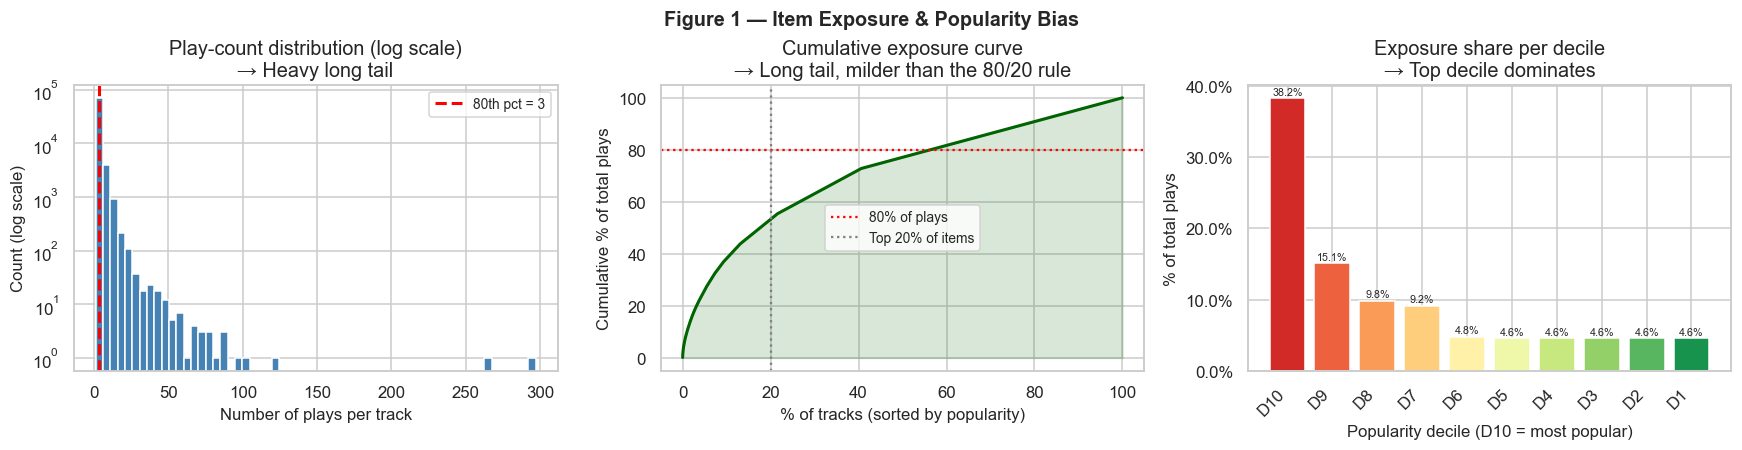

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# --- Log-scale play-count distribution ---
axes[0].hist(item_stats['n_plays'], bins=60, color='steelblue', edgecolor='white', log=True)
axes[0].axvline(pop_threshold, color='red', linestyle='--', lw=2,
                label=f'80th pct = {pop_threshold:.0f}')
axes[0].set_xlabel('Number of plays per track')
axes[0].set_ylabel('Count (log scale)')
axes[0].set_title('Play-count distribution (log scale)\n\u2192 Heavy long tail')
axes[0].legend(fontsize=9)

# --- Lorenz-style cumulative exposure ---
sorted_exp = item_stats['n_plays'].sort_values(ascending=False)
cum_share  = sorted_exp.cumsum() / sorted_exp.sum() * 100
item_pct   = np.arange(1, len(sorted_exp) + 1) / len(sorted_exp) * 100

axes[1].plot(item_pct, cum_share, color='darkgreen', lw=2)
axes[1].axhline(80, color='red', linestyle=':', lw=1.5, label='80% of plays')
axes[1].axvline(20, color='gray', linestyle=':', lw=1.5, label='Top 20% of items')
axes[1].fill_between(item_pct, cum_share, alpha=0.15, color='darkgreen')
axes[1].set_xlabel('% of tracks (sorted by popularity)')
axes[1].set_ylabel('Cumulative % of total plays')
axes[1].set_title('Cumulative exposure curve\n\u2192 Long tail, milder than the 80/20 rule')
axes[1].legend(fontsize=9)

# --- Popularity decile exposure share ---
item_stats['decile'] = pd.qcut(
    item_stats['n_plays'].rank(method='first'), q=10,
    labels=[f'D{i}' for i in range(1, 11)]
)
decile_exp = (
    item_stats.groupby('decile', observed=True)['n_plays'].sum()
    / item_stats['n_plays'].sum() * 100
).sort_index(ascending=False)

colors = sns.color_palette('RdYlGn', 10)
axes[2].bar(range(10), decile_exp.values, color=colors, edgecolor='white')
axes[2].set_xticks(range(10))
axes[2].set_xticklabels(decile_exp.index, rotation=45, ha='right')
axes[2].set_xlabel('Popularity decile (D10 = most popular)')
axes[2].set_ylabel('% of total plays')
axes[2].set_title('Exposure share per decile\n\u2192 Top decile dominates')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
for i, v in enumerate(decile_exp.values):
    axes[2].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=7)

plt.tight_layout()
plt.suptitle('Figure 1 \u2014 Item Exposure & Popularity Bias', y=1.02, fontsize=13, fontweight='bold')
plt.show()

### Simple Explanation - Figure 1

This figure demonstrates item exposure and popularity bias in the Last.fm listening data.

**What each graph shows:**
- **Left graph:** Shows how many plays each track receives. It demonstrates that most tracks have very few plays, while a smaller group receives many plays.
- **Middle graph:** Shows cumulative exposure. It demonstrates how much of total listening is captured by the most played tracks.
- **Right graph:** Shows play exposure by item decile. It demonstrates that the top popularity groups receive much more listening than lower groups.

**Simple takeaway:** Listening attention follows a long-tail pattern. Popular tracks are highly visible, while many niche tracks receive little exposure.

---
## 3 — Play-Count "Rating" Distribution

Last.fm has no explicit 1–5 rating — listening *is* the rating. We use play count per
track as the implicit-feedback analogue, and compare how repeat-play behaviour differs
between popular and niche tracks.

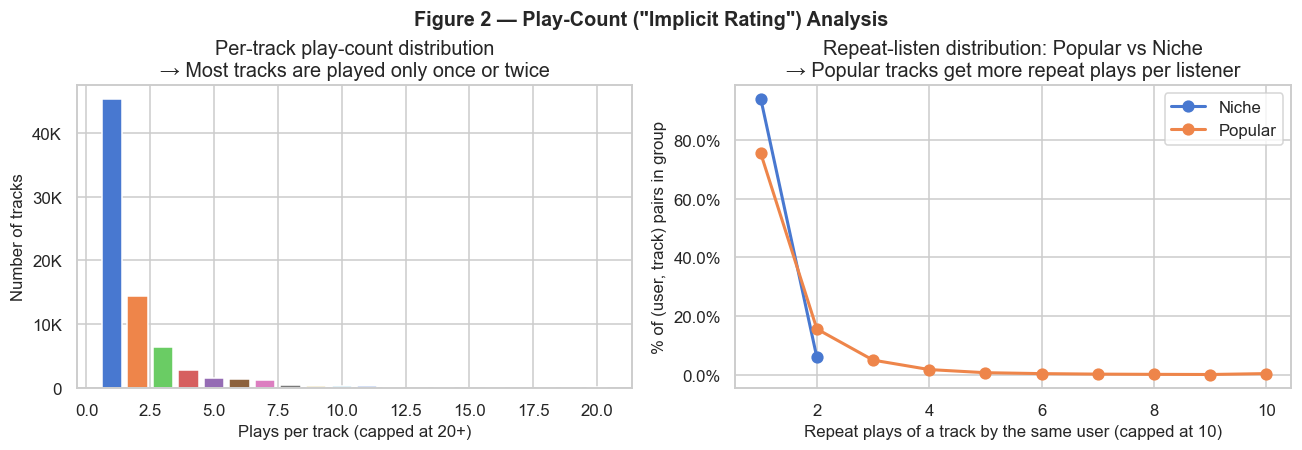

Mean repeat-plays per (user,track) — Popular items: 1.463
Mean repeat-plays per (user,track) — Niche items  : 1.059


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Overall per-track play-count distribution (capped for readability) ---
pc = item_stats['n_plays'].clip(upper=20).value_counts().sort_index()
axes[0].bar(pc.index, pc.values, color=sns.color_palette('muted', len(pc)), edgecolor='white')
axes[0].set_xlabel('Plays per track (capped at 20+)')
axes[0].set_ylabel('Number of tracks')
axes[0].set_title('Per-track play-count distribution\n\u2192 Most tracks are played only once or twice')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K' if x >= 1e3 else f'{x:.0f}'))

# --- Mean plays-per-user-encounter: popular vs niche ---
scrobble_pop = scrobbles.merge(item_stats[['ItemKey', 'is_popular']], on='ItemKey')
per_user_item_plays = (
    scrobble_pop.groupby(['Username', 'ItemKey', 'is_popular']).size()
    .rename('plays').reset_index()
)
per_user_item_plays['Popularity'] = per_user_item_plays['is_popular'].map({1: 'Popular', 0: 'Niche'})

for label, grp in per_user_item_plays.groupby('Popularity'):
    rc_grp = grp['plays'].clip(upper=10).value_counts(normalize=True).sort_index()
    axes[1].plot(rc_grp.index, rc_grp.values * 100, 'o-', lw=2, ms=7, label=label)

axes[1].set_xlabel('Repeat plays of a track by the same user (capped at 10)')
axes[1].set_ylabel('% of (user, track) pairs in group')
axes[1].set_title('Repeat-listen distribution: Popular vs Niche\n\u2192 Popular tracks get more repeat plays per listener')
axes[1].legend()
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))

plt.tight_layout()
plt.suptitle('Figure 2 \u2014 Play-Count ("Implicit Rating") Analysis', y=1.02, fontsize=13, fontweight='bold')
plt.show()

print('Mean repeat-plays per (user,track) \u2014 Popular items:',
      per_user_item_plays[per_user_item_plays.is_popular==1]['plays'].mean().round(3))
print('Mean repeat-plays per (user,track) \u2014 Niche items  :',
      per_user_item_plays[per_user_item_plays.is_popular==0]['plays'].mean().round(3))

### Simple Explanation - Figure 2

This figure demonstrates play count as an implicit rating signal.

**What each graph shows:**
- **Left graph:** Shows how many tracks have 1 play, 2 plays, and so on, with high values capped for readability. It demonstrates that most tracks are played only once or a few times.
- **Right graph:** Compares repeat-listening patterns for popular and niche tracks. It demonstrates whether popular tracks are replayed more often by users.

**Simple takeaway:** Repeated listening acts like a stronger preference signal. Popular tracks usually get more repeat plays, while many tracks remain one-time listens.

---
## 4 — Artist Landscape

Last.fm carries no explicit genre field, so we use **Artist** as the categorical label
a track belongs to — the direct analogue of `Genre` in MovieLens. Unlike movie genres,
artist membership is single-label (one track → exactly one artist), which makes the
calibration question slightly simpler but the same in spirit: do the artists a user
actually listens to retain their proportions once content is exposed/recommended?

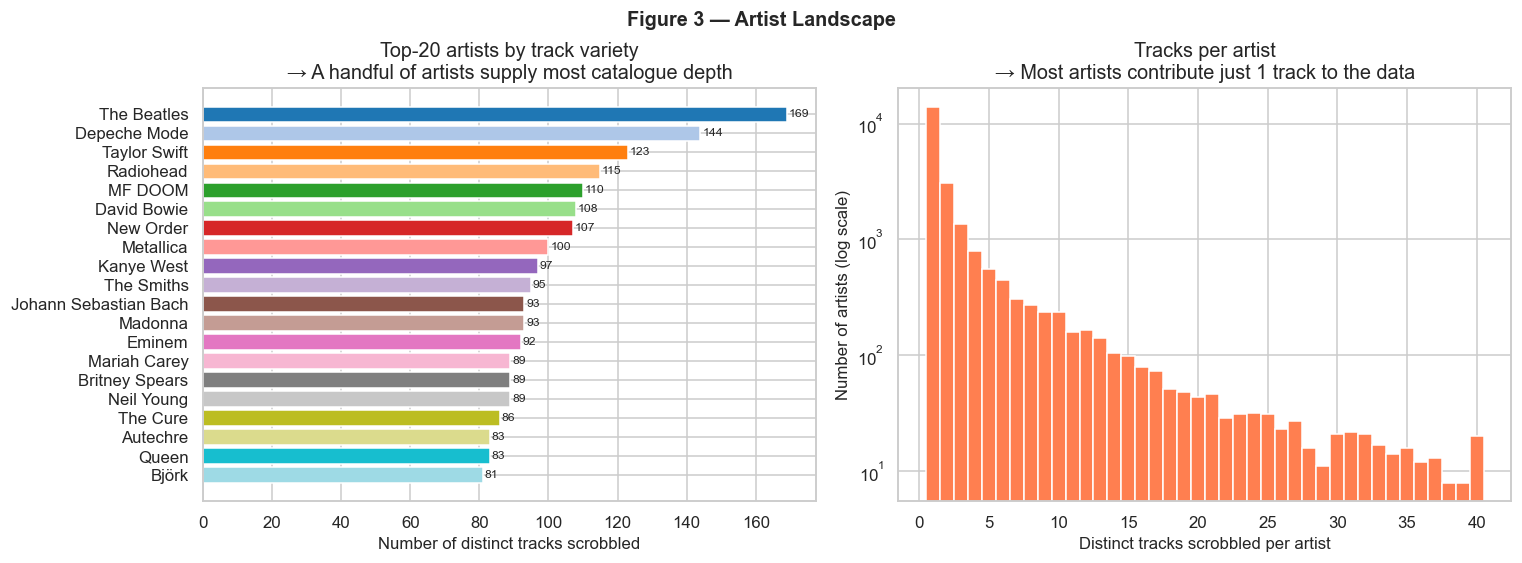

Unique artists      : 22823
Avg tracks / artist : 3.33


In [8]:
artist_track_counts = item_stats.groupby('Artist')['ItemKey'].nunique().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Top-20 artists by number of distinct tracks scrobbled ---
top20 = artist_track_counts.head(20)
palette = sns.color_palette('tab20', len(top20))
axes[0].barh(top20.index[::-1], top20.values[::-1], color=palette[::-1], edgecolor='white')
axes[0].set_xlabel('Number of distinct tracks scrobbled')
axes[0].set_title('Top-20 artists by track variety\n\u2192 A handful of artists supply most catalogue depth')
for i, v in enumerate(top20.values[::-1]):
    axes[0].text(v + 0.5, i, str(v), va='center', fontsize=8)

# --- Distribution of tracks-per-artist (artist "breadth") ---
axes[1].hist(artist_track_counts, bins=range(1, min(40, artist_track_counts.max())+2),
             color='coral', edgecolor='white', align='left', log=True)
axes[1].set_xlabel('Distinct tracks scrobbled per artist')
axes[1].set_ylabel('Number of artists (log scale)')
axes[1].set_title('Tracks per artist\n\u2192 Most artists contribute just 1 track to the data')

plt.tight_layout()
plt.suptitle('Figure 3 \u2014 Artist Landscape', y=1.02, fontsize=13, fontweight='bold')
plt.show()

print('Unique artists      :', n_artists)
print('Avg tracks / artist :', artist_track_counts.mean().round(2))

### Simple Explanation - Figure 3

This figure demonstrates the artist structure of the Last.fm catalogue.

**What each graph shows:**
- **Left graph:** Shows the top 20 artists by number of distinct tracks. It demonstrates which artists supply the most catalogue depth.
- **Right graph:** Shows the distribution of tracks per artist. It demonstrates that many artists appear with only one or a few tracks.

**Simple takeaway:** Artist representation is uneven. Some artists have many tracks in the data, while many artists have very limited presence.

---
## 5 — Artist-Level Exposure Inequality

Aggregating plays by artist mirrors the genre-level exposure analysis in MovieLens:
how unevenly is listening time distributed across artists, and which artists are
"exposure-efficient" (high plays per track) versus simply prolific?

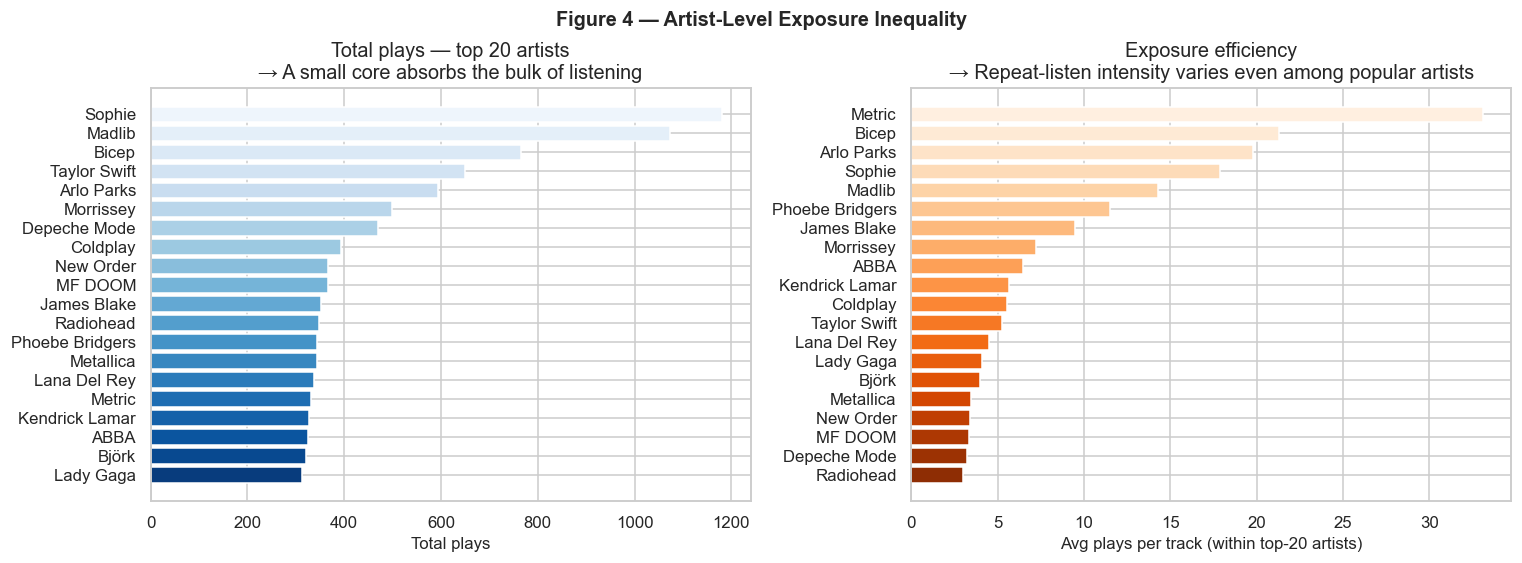

,total_plays,n_tracks,n_users,plays_per_track
Artist,,,,
Sophie,1181,66,8,17.893939
Madlib,1074,75,11,14.320000
Bicep,766,36,11,21.277778
Taylor Swift,649,123,11,5.276423
Arlo Parks,593,30,11,19.766667
Morrissey,498,69,11,7.217391
Depeche Mode,469,144,11,3.256944
Coldplay,393,71,8,5.535211
New Order,367,107,7,3.429907


In [9]:
artist_exposure = (
    scrobbles.groupby('Artist')
    .agg(
        total_plays = ('Username', 'count'),
        n_tracks    = ('ItemKey', 'nunique'),
        n_users     = ('Username', 'nunique'),
    )
    .reset_index()
)
artist_exposure['plays_per_track'] = (
    artist_exposure['total_plays'] / artist_exposure['n_tracks']
)
artist_exposure = artist_exposure.sort_values('total_plays', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Total plays for top-20 artists ---
top_artists = artist_exposure.head(20)
palette = sns.color_palette('Blues_r', len(top_artists))
axes[0].barh(top_artists['Artist'][::-1], top_artists['total_plays'][::-1],
             color=palette, edgecolor='white')
axes[0].set_xlabel('Total plays')
axes[0].set_title('Total plays \u2014 top 20 artists\n\u2192 A small core absorbs the bulk of listening')

# --- Plays-per-track (exposure efficiency) for the same top-20 ---
te_sorted = top_artists.sort_values('plays_per_track', ascending=False)
axes[1].barh(te_sorted['Artist'][::-1], te_sorted['plays_per_track'][::-1],
             color=sns.color_palette('Oranges_r', len(te_sorted)), edgecolor='white')
axes[1].set_xlabel('Avg plays per track (within top-20 artists)')
axes[1].set_title('Exposure efficiency\n\u2192 Repeat-listen intensity varies even among popular artists')

plt.tight_layout()
plt.suptitle('Figure 4 \u2014 Artist-Level Exposure Inequality', y=1.02, fontsize=13, fontweight='bold')
plt.show()

display(artist_exposure.head(15).set_index('Artist'))

### Simple Explanation - Figure 4

This figure demonstrates artist-level exposure inequality.

**What each graph shows:**
- **Left graph:** Shows total plays for the top artists. It demonstrates which artists receive the most listening attention overall.
- **Right graph:** Shows average plays per track for those artists. It demonstrates which artists are exposure-efficient, not just represented by many tracks.

**Simple takeaway:** A small artist core absorbs much of the listening. Some artists are popular because they have many tracks, while others get high listening intensity per track.

---
## 6 — User Activity Distribution

With only a handful of users in this export, the population is far smaller than
MovieLens's user base — but the same questions apply: how active is each listener,
and how much does listening intensity vary?

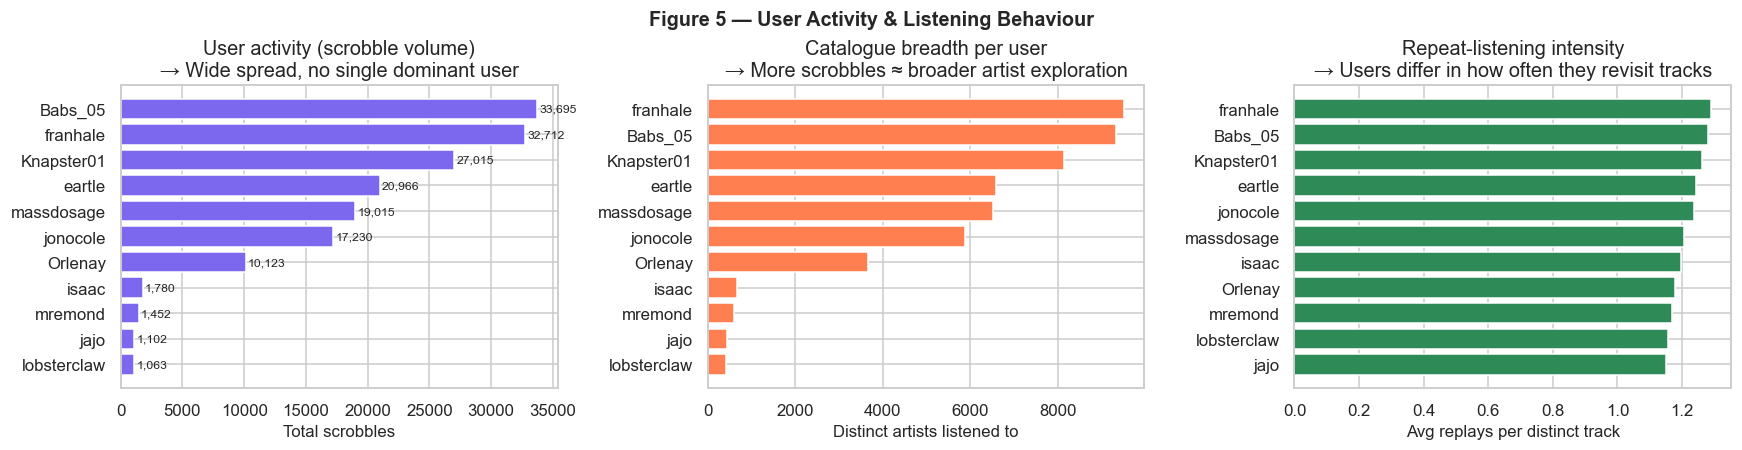

User activity summary:


,n_scrobbles,n_items,n_artists,repeat_rate
count,11.00,11.00,11.00,11.00
mean,15104.82,12081.09,4708.18,1.22
std,12781.39,9986.52,3677.39,0.05
min,1063.00,919.00,428.00,1.15
25%,1616.00,1366.00,634.50,1.17
50%,17230.00,13930.00,5884.00,1.21
75%,23990.50,19142.00,7372.50,1.25
max,33695.00,26329.00,9504.00,1.29


In [10]:
user_activity = (
    scrobbles.groupby('Username')
    .agg(
        n_scrobbles = ('ItemKey', 'count'),
        n_items     = ('ItemKey', 'nunique'),
        n_artists   = ('Artist', 'nunique'),
    )
    .reset_index()
)
# Repeat-rate: how many times, on average, each distinct track is replayed by this user
user_activity['repeat_rate'] = user_activity['n_scrobbles'] / user_activity['n_items']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# --- Scrobbles per user ---
order = user_activity.sort_values('n_scrobbles', ascending=True)
axes[0].barh(order['Username'], order['n_scrobbles'], color='mediumslateblue', edgecolor='white')
axes[0].set_xlabel('Total scrobbles')
axes[0].set_title('User activity (scrobble volume)\n\u2192 Wide spread, no single dominant user')
for i, v in enumerate(order['n_scrobbles']):
    axes[0].text(v + 200, i, f'{v:,}', va='center', fontsize=8)

# --- Distinct artists explored per user ---
order2 = user_activity.sort_values('n_artists', ascending=True)
axes[1].barh(order2['Username'], order2['n_artists'], color='coral', edgecolor='white')
axes[1].set_xlabel('Distinct artists listened to')
axes[1].set_title('Catalogue breadth per user\n\u2192 More scrobbles \u2248 broader artist exploration')

# --- Repeat-rate per user ---
order3 = user_activity.sort_values('repeat_rate', ascending=True)
axes[2].barh(order3['Username'], order3['repeat_rate'], color='seagreen', edgecolor='white')
axes[2].set_xlabel('Avg replays per distinct track')
axes[2].set_title('Repeat-listening intensity\n\u2192 Users differ in how often they revisit tracks')

plt.tight_layout()
plt.suptitle('Figure 5 \u2014 User Activity & Listening Behaviour', y=1.02, fontsize=13, fontweight='bold')
plt.show()

print('User activity summary:')
display(user_activity.describe().round(2))

### Simple Explanation - Figure 5

This figure demonstrates user activity and listening behavior.

**What each graph shows:**
- **Left graph:** Shows total scrobbles per user. It demonstrates how much listening volume differs across users.
- **Middle graph:** Shows distinct artists explored by each user. It demonstrates the breadth of each user's listening.
- **Right graph:** Shows repeat rate per user. It demonstrates how often users replay the same tracks instead of exploring new ones.

**Simple takeaway:** Users listen in different ways. Some users are heavy listeners, some explore many artists, and some repeat familiar tracks more often.

---
## 7 — User Listening-Time Behaviour

Last.fm carries no demographic fields (gender/age), so we substitute the closest
available behavioural signal: **when** a user listens. This plays the same structural
role as the demographics section in the MovieLens notebook — a facet that segments
users into groups whose preferences can later be compared.

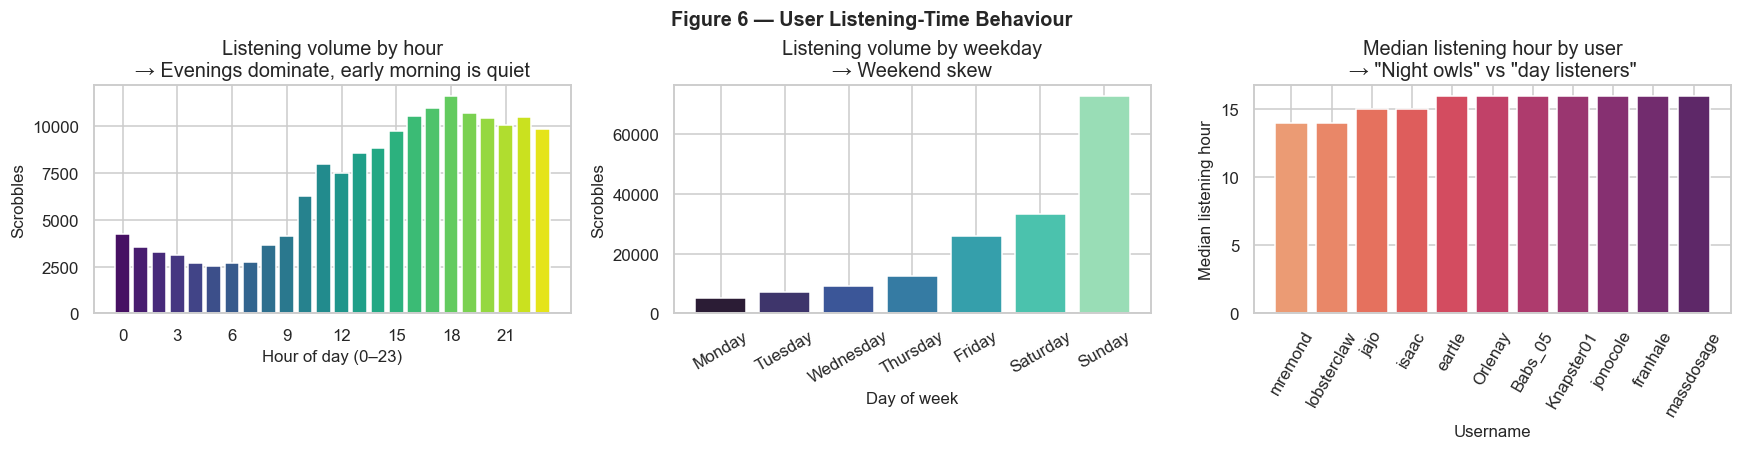

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# --- Listening volume by hour of day (all users pooled) ---
hour_counts = scrobbles['Hour'].value_counts().sort_index()
axes[0].bar(hour_counts.index, hour_counts.values,
            color=sns.color_palette('viridis', 24), edgecolor='white')
axes[0].set_xlabel('Hour of day (0\u201323)')
axes[0].set_ylabel('Scrobbles')
axes[0].set_title('Listening volume by hour\n\u2192 Evenings dominate, early morning is quiet')
axes[0].set_xticks(range(0, 24, 3))

# --- Listening volume by day of week ---
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = scrobbles['DayOfWeek'].value_counts().reindex(day_order, fill_value=0)
axes[1].bar(day_counts.index, day_counts.values,
            color=sns.color_palette('mako', 7), edgecolor='white')
axes[1].set_xlabel('Day of week')
axes[1].set_ylabel('Scrobbles')
axes[1].set_title('Listening volume by weekday\n\u2192 Weekend skew')
axes[1].tick_params(axis='x', rotation=30)

# --- Median listening hour per user ---
median_hour_by_user = scrobbles.groupby('Username')['Hour'].median().sort_values()
axes[2].bar(median_hour_by_user.index, median_hour_by_user.values,
            color=sns.color_palette('flare', len(median_hour_by_user)), edgecolor='white')
axes[2].set_xlabel('Username')
axes[2].set_ylabel('Median listening hour')
axes[2].set_title('Median listening hour by user\n\u2192 "Night owls" vs "day listeners"')
axes[2].tick_params(axis='x', rotation=60)

plt.tight_layout()
plt.suptitle('Figure 6 \u2014 User Listening-Time Behaviour', y=1.02, fontsize=13, fontweight='bold')
plt.show()

### Simple Explanation - Figure 6

This figure demonstrates when users listen to music.

**What each graph shows:**
- **Left graph:** Shows listening volume by hour of day. It demonstrates the daily listening pattern, including busier and quieter hours.
- **Middle graph:** Shows listening volume by weekday. It demonstrates whether listening is stronger on certain days.
- **Right graph:** Shows median listening hour by user. It demonstrates whether users tend to listen earlier or later in the day.

**Simple takeaway:** Listening time is a useful behavioral feature. Since demographic data is not available, time patterns help describe user habits.

---
## 8 — Artist Preference by User

The analogue of "genre preference by demographic group": which artists dominate
each user's listening, and how much overlap is there in taste across the small
user population?

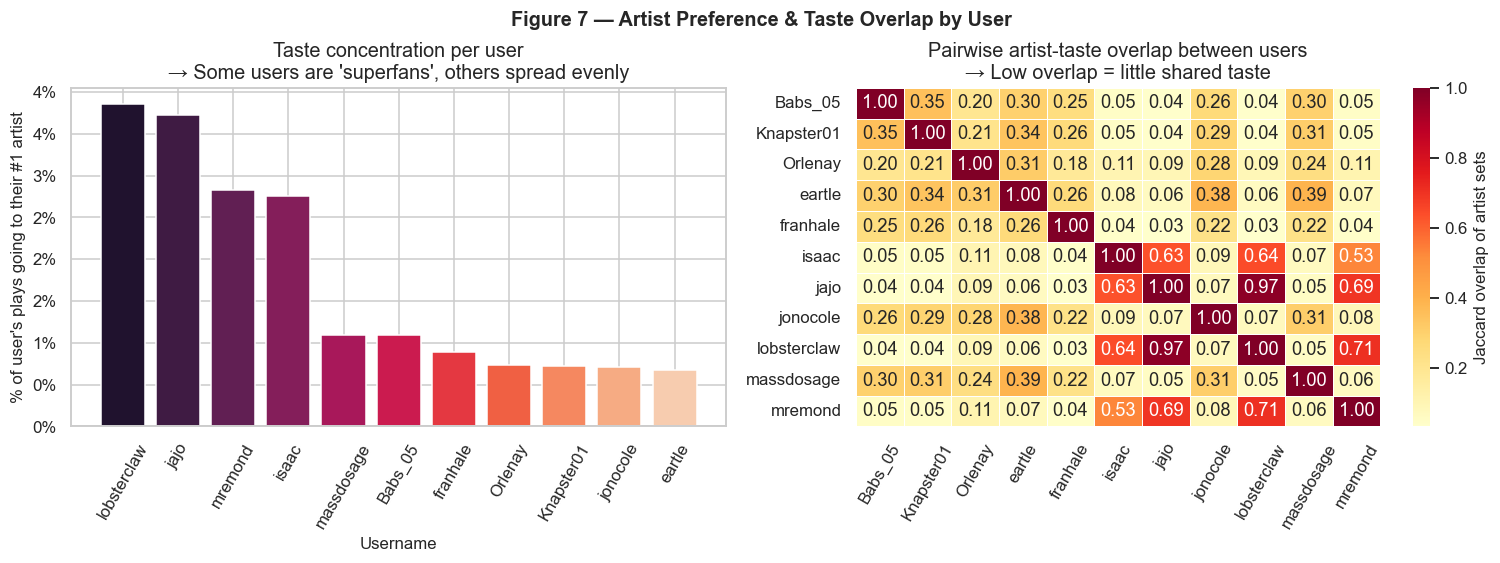

In [12]:
# --- Top artist share per user (how concentrated is each user's taste?) ---
top_artist_per_user = (
    scrobbles.groupby(['Username', 'Artist']).size()
    .rename('plays').reset_index()
    .sort_values(['Username', 'plays'], ascending=[True, False])
)
top1_share = (
    top_artist_per_user.groupby('Username')
    .apply(lambda g: g['plays'].iloc[0] / g['plays'].sum() * 100, include_groups=False)
    .rename('top_artist_share_pct')
)

# --- Pairwise user-artist taste overlap (Jaccard on artist sets) ---
user_artist_sets = scrobbles.groupby('Username')['Artist'].apply(set)
usernames = user_artist_sets.index.tolist()
overlap = pd.DataFrame(index=usernames, columns=usernames, dtype=float)
for u1 in usernames:
    for u2 in usernames:
        a, b = user_artist_sets[u1], user_artist_sets[u2]
        overlap.loc[u1, u2] = len(a & b) / len(a | b) if len(a | b) > 0 else 0.0

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = top1_share.sort_values(ascending=False)
axes[0].bar(order.index, order.values,
            color=sns.color_palette('rocket', len(order)), edgecolor='white')
axes[0].set_xlabel('Username')
axes[0].set_ylabel("% of user's plays going to their #1 artist")
axes[0].set_title("Taste concentration per user\n\u2192 Some users are 'superfans', others spread evenly")
axes[0].tick_params(axis='x', rotation=60)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

sns.heatmap(overlap.astype(float), ax=axes[1], cmap='YlOrRd', annot=True, fmt='.2f',
            linewidths=0.4, cbar_kws={'label': 'Jaccard overlap of artist sets'})
axes[1].set_title('Pairwise artist-taste overlap between users\n\u2192 Low overlap = little shared taste')
axes[1].tick_params(axis='x', rotation=60)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.suptitle('Figure 7 \u2014 Artist Preference & Taste Overlap by User', y=1.02, fontsize=13, fontweight='bold')
plt.show()

### Simple Explanation - Figure 7

This figure demonstrates artist preference concentration and taste overlap between users.

**What each graph shows:**
- **Left graph:** Shows the percentage of each user's plays going to their number-one artist. It demonstrates how concentrated or focused each user's taste is.
- **Right graph:** Shows pairwise artist overlap between users using a heatmap. It demonstrates whether users listen to similar artist sets.

**Simple takeaway:** Some users are strongly focused on a favorite artist, while others are more spread out. User overlap is important for collaborative recommendation.

---
## 9 — User Artist Diversity (Calibration Baseline)

For each user we compute their **selection distribution** over artists — the proportion
of their scrobbles that belong to each artist. This is the per-user profile a calibrated
recommender should mirror, exactly as the genre selection-distribution was used in the
MovieLens notebook. We measure how *diverse* this profile is via normalised Shannon entropy,
and check whether more active users tend to be more (or less) diverse listeners.

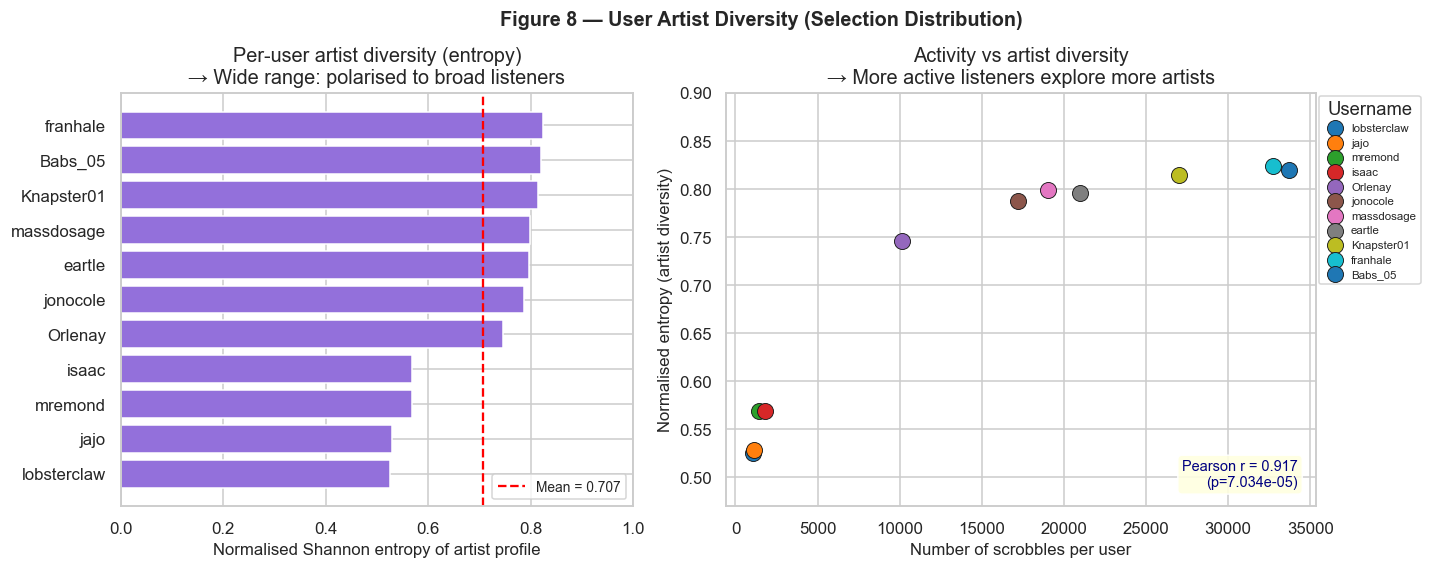

Mean normalised entropy : 0.7071
Std                     : 0.1285
Most polarised listener : lobsterclaw (0.5251)
Most diverse listener   : franhale (0.8237)


In [16]:
from scipy.stats import entropy as scipy_entropy

n_artists_total = scrobbles['Artist'].nunique()

def normalised_entropy(series, n_total):
    # Shannon entropy of an artist distribution, normalised to [0,1].
    p = series.value_counts(normalize=True).values
    if len(p) == 0:
        return 0.0
    h = scipy_entropy(p, base=2)
    h_max = np.log2(n_total)
    return float(h / h_max) if h_max > 0 else 0.0

# All 11 users are used (small population — no need to sub-sample as in MovieLens)
user_entropy = (
    scrobbles.groupby('Username')['Artist']
    .apply(lambda s: normalised_entropy(s, n_artists_total))
    .reset_index()
    .rename(columns={'Artist': 'NormEntropy'})
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [1, 1.15]})

# --- Bar chart of per-user diversity (histogram is uninformative with only 11 users) ---
order = user_entropy.sort_values('NormEntropy')
axes[0].barh(order['Username'], order['NormEntropy'],
             color='mediumpurple', edgecolor='white')
axes[0].axvline(user_entropy['NormEntropy'].mean(), color='red', linestyle='--', lw=1.5,
                label=f'Mean = {user_entropy["NormEntropy"].mean():.3f}')
axes[0].set_xlabel('Normalised Shannon entropy of artist profile')
axes[0].set_title('Per-user artist diversity (entropy)\n\u2192 Wide range: polarised to broad listeners')
axes[0].set_xlim(0, 1.0)
axes[0].legend(fontsize=9, loc='lower right')

# --- Diversity vs activity: one distinct colour per user, resolved via legend (no text labels at all) ---
entropy_activity = user_entropy.merge(user_activity[['Username', 'n_scrobbles']], on='Username')
entropy_activity = entropy_activity.sort_values('n_scrobbles').reset_index(drop=True)

users_list = entropy_activity['Username'].tolist()
palette = sns.color_palette('tab10', len(users_list))

for color, (_, row) in zip(palette, entropy_activity.iterrows()):
    axes[1].scatter(
        row['n_scrobbles'], row['NormEntropy'],
        s=110, color=color, edgecolors='k', linewidths=0.6,
        label=row['Username'], zorder=3
    )

r, p = pearsonr(entropy_activity['n_scrobbles'], entropy_activity['NormEntropy'])
axes[1].set_xlabel('Number of scrobbles per user')
axes[1].set_ylabel('Normalised entropy (artist diversity)')
axes[1].set_title('Activity vs artist diversity\n\u2192 More active listeners explore more artists')
axes[1].set_ylim(0.47, 0.90)
axes[1].legend(fontsize=7.5, loc='upper left', bbox_to_anchor=(1.0, 1.0),
               title='Username', frameon=True, borderaxespad=0.3,
               handletextpad=0.4, labelspacing=0.4)
axes[1].text(0.97, 0.04, f'Pearson r = {r:.3f}\n(p={p:.3e})',
             transform=axes[1].transAxes, fontsize=9.5, color='navy',
             ha='right', va='bottom',
             bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.9))

plt.tight_layout()
plt.subplots_adjust(right=0.86)
plt.suptitle('Figure 8 \u2014 User Artist Diversity (Selection Distribution)', y=1.03, fontsize=13, fontweight='bold')
plt.show()

print(f'Mean normalised entropy : {user_entropy["NormEntropy"].mean():.4f}')
print(f'Std                     : {user_entropy["NormEntropy"].std():.4f}')
print(f'Most polarised listener : {user_entropy.loc[user_entropy["NormEntropy"].idxmin(), "Username"]} '
      f'({user_entropy["NormEntropy"].min():.4f})')
print(f'Most diverse listener   : {user_entropy.loc[user_entropy["NormEntropy"].idxmax(), "Username"]} '
      f'({user_entropy["NormEntropy"].max():.4f})')

### Simple Explanation - Figure 8

This figure demonstrates user-level artist diversity.

**What each graph shows:**
- **Left graph:** Shows normalized artist entropy for each user. It demonstrates whether each user's listening is narrow or broad across artists.
- **Right graph:** Shows the relationship between user activity and artist diversity. It demonstrates whether more active users also explore a wider artist range.

**Simple takeaway:** Users have different diversity needs. A good music recommender should adapt to focused listeners and broad listeners differently.

---
## 10 — Niche Artist Exposure vs Co-Listening Similarity

A key question for recommendation: if we force more niche artists into a recommendation
list (to improve fairness), do those niche artists tend to be redundant with each other —
i.e. listened to by the same narrow slice of users — more than popular artists are?

MovieLens answered this with genre cosine similarity. Here there is no genre field, so we
build the analogous similarity space from **co-listening**: each artist is represented as a
vector over the 11 users (how much each user has played them), L2-normalised, and we compare
mean pairwise cosine similarity between popular and niche artists.

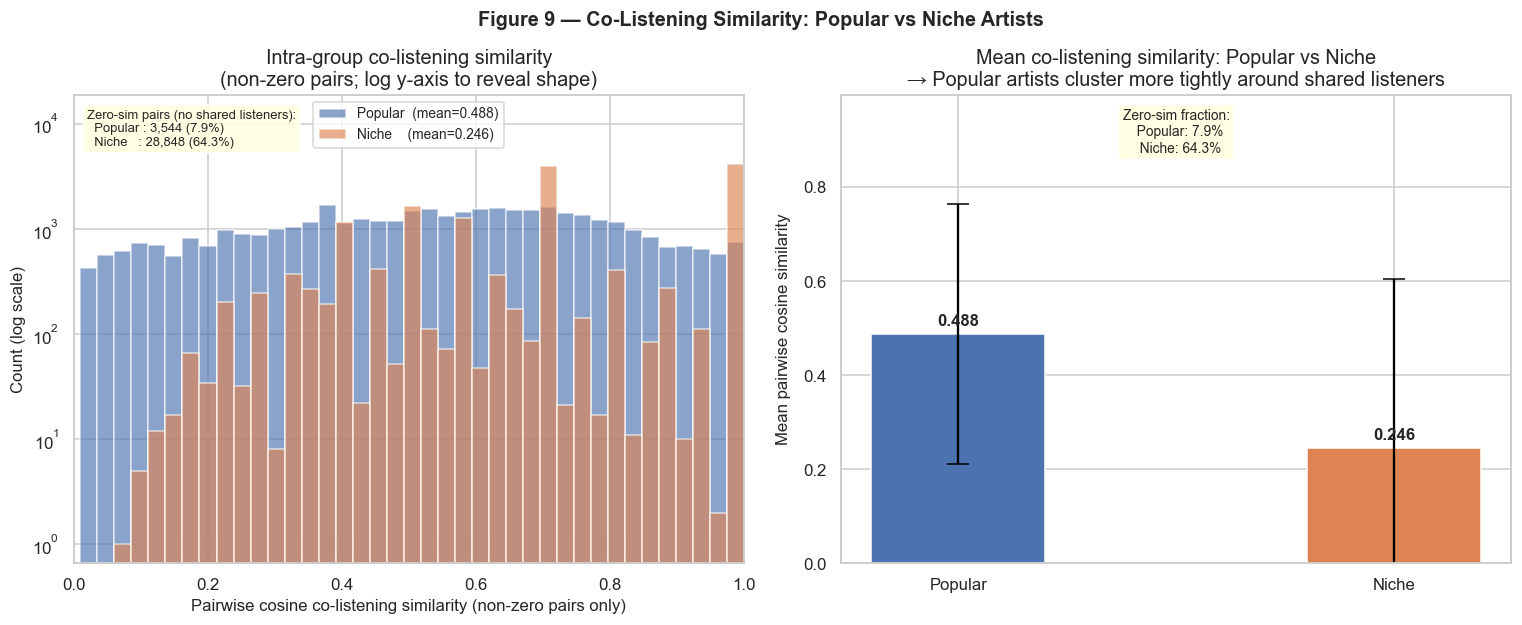

Popular — mean pairwise co-listening similarity : 0.4883 ± 0.2762
Niche   — mean pairwise co-listening similarity : 0.2460 ± 0.3581
Popular zero-sim fraction : 7.9%
Niche   zero-sim fraction : 64.3%

Interpretation: with only 11 listeners, popular artists are almost always shared by
several users at once, so their co-listening vectors overlap heavily (high similarity).
Niche artists are usually tied to one or two listeners, so most niche pairs share no
listener at all (high zero-sim fraction) — the opposite texture from MovieLens genre overlap,
but the same underlying risk: boosting niche exposure changes the redundancy profile of the
list, and that interaction needs an explicit term rather than being left to chance.


In [14]:
# Build a user-listener vector per artist: rows = artists, cols = the 11 users
user_artist_matrix = (
    scrobbles.groupby(['Artist', 'Username']).size()
    .unstack(fill_value=0)
)

artist_pop = artist_exposure.set_index('Artist')
artist_pop_thr = artist_pop['total_plays'].quantile(0.80)
artist_pop['is_popular'] = (artist_pop['total_plays'] >= artist_pop_thr).astype(int)

common_artists = user_artist_matrix.index.intersection(artist_pop.index)
ua = user_artist_matrix.loc[common_artists]
pop_flags = artist_pop.loc[common_artists, 'is_popular']

mat = ua.values.astype(float)
norms = np.linalg.norm(mat, axis=1, keepdims=True)
norms[norms == 0] = 1
mat_norm = mat / norms

popular_mat = mat_norm[pop_flags.values == 1]
niche_mat   = mat_norm[pop_flags.values == 0]

# Sample subsets for tractability (same convention as MovieLens — n_sample=300)
rng = np.random.default_rng(42)
n_sample = 300
pop_sample   = popular_mat[rng.choice(len(popular_mat), min(n_sample, len(popular_mat)), replace=False)]
niche_sample = niche_mat[rng.choice(len(niche_mat), min(n_sample, len(niche_mat)), replace=False)]

sim_popular = (pop_sample @ pop_sample.T)[np.triu_indices(len(pop_sample), k=1)]
sim_niche   = (niche_sample @ niche_sample.T)[np.triu_indices(len(niche_sample), k=1)]

pop_mean, pop_std     = float(sim_popular.mean()), float(sim_popular.std())
niche_mean, niche_std = float(sim_niche.mean()),   float(sim_niche.std())

zero_pop   = int((sim_popular == 0).sum())
zero_niche = int((sim_niche   == 0).sum())

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# --- Left: non-zero pairs, log y-axis ---
pop_nonzero   = sim_popular[sim_popular > 0]
niche_nonzero = sim_niche[sim_niche > 0]
bins = np.linspace(0.01, 1, 40)

axes[0].hist(pop_nonzero,   bins=bins, alpha=0.65, color='#4C72B0',
             label=f'Popular  (mean={pop_mean:.3f})', log=True)
axes[0].hist(niche_nonzero, bins=bins, alpha=0.65, color='#DD8452',
             label=f'Niche    (mean={niche_mean:.3f})', log=True)
axes[0].set_xlabel('Pairwise cosine co-listening similarity (non-zero pairs only)')
axes[0].set_ylabel('Count (log scale)')
axes[0].set_title('Intra-group co-listening similarity\n(non-zero pairs; log y-axis to reveal shape)')
axes[0].set_xlim(0, 1)
axes[0].set_ylim(top=axes[0].get_ylim()[1] * 3)  # headroom so legend doesn't sit on bars
axes[0].legend(fontsize=9, loc='upper center')
axes[0].annotate(
    f'Zero-sim pairs (no shared listeners):\n'
    f'  Popular : {zero_pop:,} ({100*zero_pop/len(sim_popular):.1f}%)\n'
    f'  Niche   : {zero_niche:,} ({100*zero_niche/len(sim_niche):.1f}%)',
    xy=(0.02, 0.97), xycoords='axes fraction',
    fontsize=8.5, va='top', ha='left',
    bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.9)
)

# --- Right: mean similarity bar chart ---
bar_vals   = [pop_mean, niche_mean]
bar_errs   = [pop_std,  niche_std]
bar_colors = ['#4C72B0', '#DD8452']
bars = axes[1].bar(['Popular', 'Niche'], bar_vals, yerr=bar_errs,
                   color=bar_colors, edgecolor='white', capsize=7, width=0.4,
                   error_kw=dict(elinewidth=1.5, ecolor='black'))
axes[1].set_ylabel('Mean pairwise cosine similarity', labelpad=8)
axes[1].set_title('Mean co-listening similarity: Popular vs Niche\n\u2192 Popular artists cluster more tightly around shared listeners')
axes[1].set_ylim(0, max(bar_vals) + max(bar_errs) + 0.15)
for bar, v in zip(bars, bar_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{v:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].annotate(
    f'Zero-sim fraction:\n  Popular: {100*(sim_popular==0).mean():.1f}%\n  Niche: {100*(sim_niche==0).mean():.1f}%',
    xy=(0.5, 0.97), xycoords='axes fraction',
    fontsize=9, va='top', ha='center',
    bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.9)
)

plt.tight_layout()
plt.suptitle('Figure 9 \u2014 Co-Listening Similarity: Popular vs Niche Artists',
             y=1.03, fontsize=13, fontweight='bold')
plt.show()

print(f'Popular \u2014 mean pairwise co-listening similarity : {pop_mean:.4f} \u00b1 {pop_std:.4f}')
print(f'Niche   \u2014 mean pairwise co-listening similarity : {niche_mean:.4f} \u00b1 {niche_std:.4f}')
print(f'Popular zero-sim fraction : {100*(sim_popular==0).mean():.1f}%')
print(f'Niche   zero-sim fraction : {100*(sim_niche==0).mean():.1f}%')
print()
print('Interpretation: with only 11 listeners, popular artists are almost always shared by')
print('several users at once, so their co-listening vectors overlap heavily (high similarity).')
print('Niche artists are usually tied to one or two listeners, so most niche pairs share no')
print('listener at all (high zero-sim fraction) \u2014 the opposite texture from MovieLens genre overlap,')
print('but the same underlying risk: boosting niche exposure changes the redundancy profile of the')
print('list, and that interaction needs an explicit term rather than being left to chance.')

### Simple Explanation - Figure 9

This figure demonstrates co-listening similarity for popular and niche artists.

**What each graph shows:**
- **Left graph:** Shows the distribution of non-zero co-listening similarity values for popular and niche artists. It demonstrates how strongly artists in each group are connected through shared listeners.
- **Right graph:** Compares mean co-listening similarity for popular and niche artists. It demonstrates which group clusters more tightly around the same users.

**Simple takeaway:** Popular artists are more shared across users, while niche artists are often more user-specific. This affects both recommendation fairness and personalization.

---
## 11 — Aggregate Diversity vs Niche Exposure Correlation

We simulate recommendation lists of varying niche fraction (from 0% to 100% niche)
and measure the resulting aggregate diversity (unique items coverage) to confirm that
**fairness and aggregate diversity are positively correlated** from the data structure itself
— the same relationship the MovieLens EDA surfaced.

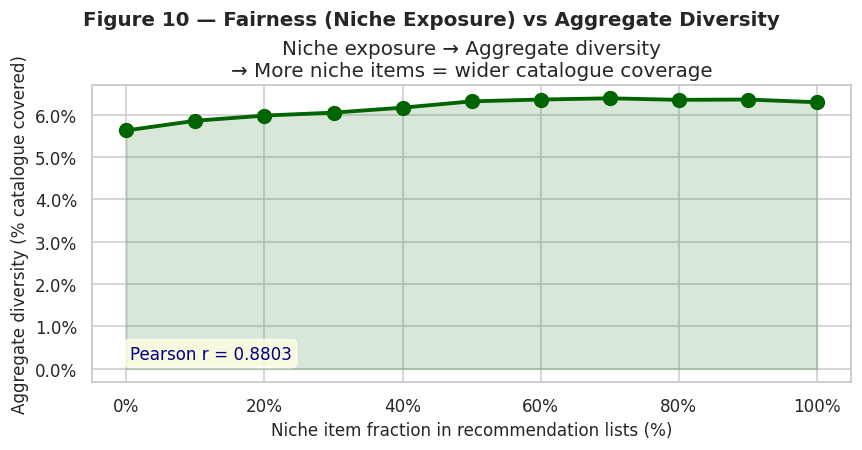

Pearson r (niche_frac vs AggDiv) = 0.8803
→ Strong positive correlation: improving item fairness expands catalogue coverage,
  the same structural relationship found in the MovieLens EDA.


In [14]:
# For each of 500 simulated users, draw a recommendation list
# with a controlled niche fraction and measure aggregate diversity

popular_ids = item_stats[item_stats['is_popular'] == 1]['ItemKey'].values
niche_ids   = item_stats[item_stats['is_popular'] == 0]['ItemKey'].values

n_sim_users = 500
K           = 10
niche_fracs = np.arange(0.0, 1.05, 0.1)

rows_sim = []
rng = np.random.default_rng(42)

for nf in niche_fracs:
    n_niche   = int(round(K * nf))
    n_popular = K - n_niche
    all_recs  = set()

    for _ in range(n_sim_users):
        rec = []
        if n_popular > 0 and len(popular_ids) >= n_popular:
            rec += rng.choice(popular_ids, n_popular, replace=False).tolist()
        if n_niche > 0 and len(niche_ids) >= n_niche:
            rec += rng.choice(niche_ids, n_niche, replace=False).tolist()
        all_recs.update(rec)

    agg_div = len(all_recs) / n_items
    rows_sim.append({'niche_frac': nf, 'AggDiv': agg_div})

sim_df = pd.DataFrame(rows_sim)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sim_df['niche_frac'] * 100, sim_df['AggDiv'] * 100, 'o-',
        color='darkgreen', lw=2.5, ms=9, zorder=3)
ax.fill_between(sim_df['niche_frac'] * 100, sim_df['AggDiv'] * 100,
                alpha=0.15, color='darkgreen')
ax.set_xlabel('Niche item fraction in recommendation lists (%)')
ax.set_ylabel('Aggregate diversity (% catalogue covered)')
ax.set_title('Niche exposure \u2192 Aggregate diversity\n\u2192 More niche items = wider catalogue coverage')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))

r, _ = pearsonr(sim_df['niche_frac'], sim_df['AggDiv'])
ax.text(0.05, 0.08, f'Pearson r = {r:.4f}', transform=ax.transAxes,
        fontsize=11, color='navy',
        bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.8))

plt.tight_layout()
plt.suptitle('Figure 10 \u2014 Fairness (Niche Exposure) vs Aggregate Diversity',
             y=1.02, fontsize=13, fontweight='bold')
plt.show()

print(f'Pearson r (niche_frac vs AggDiv) = {r:.4f}')
print('\u2192 Strong positive correlation: improving item fairness expands catalogue coverage,')
print('  the same structural relationship found in the MovieLens EDA.')

### Simple Explanation - Figure 10

This figure demonstrates the relationship between niche exposure and aggregate diversity.

**What the graph shows:**
- **Line graph:** Shows aggregate catalogue coverage as the percentage of niche tracks in recommendation lists increases. It demonstrates whether adding niche tracks exposes more unique items.

**Simple takeaway:** More niche exposure increases catalogue coverage. Recommending niche music can help the system use more of the catalogue instead of repeating only popular tracks.

---
## 12 — Popularity Bias in User Profiles vs Artist Pool

We examine whether users' consumed artist distributions match the overall artist
distribution of the catalogue — or whether popular artists distort what users
appear to prefer, exactly as popular genres distorted apparent preference in MovieLens.

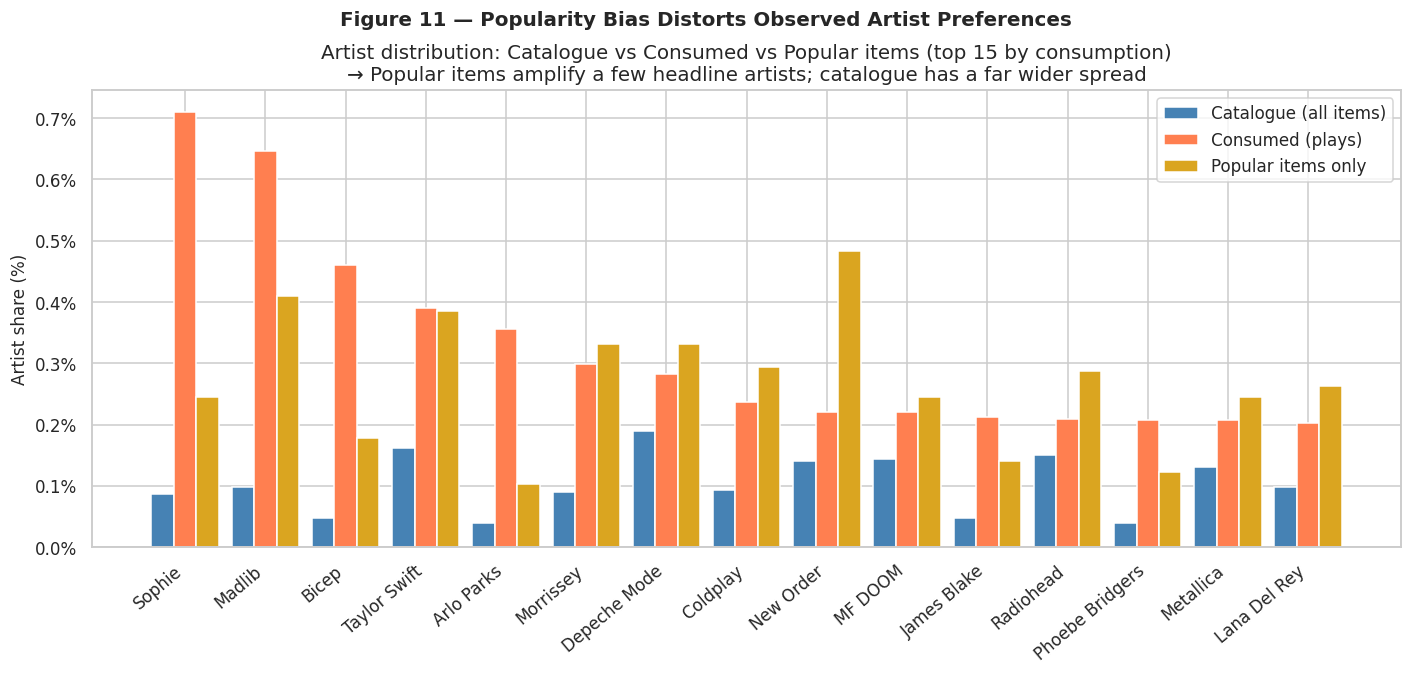

,Catalogue,Consumed,Popular items
Artist,,,
Sophie,0.0009,0.0071,0.0025
Madlib,0.0010,0.0065,0.0041
Bicep,0.0005,0.0046,0.0018
Taylor Swift,0.0016,0.0039,0.0039
Arlo Parks,0.0004,0.0036,0.0010
Morrissey,0.0009,0.0030,0.0033
Depeche Mode,0.0019,0.0028,0.0033
Coldplay,0.0009,0.0024,0.0029
New Order,0.0014,0.0022,0.0048


In [15]:
# Overall catalogue artist distribution (each track counts once toward its artist)
catalogue_artist_dist = (
    item_stats['Artist'].value_counts(normalize=True)
    .rename('Catalogue')
)

# Artist distribution weighted by plays (what users actually consumed)
consumed_artist_dist = (
    scrobbles['Artist'].value_counts(normalize=True)
    .rename('Consumed')
)

# Artist distribution restricted to popular items only
popular_item_keys = item_stats[item_stats['is_popular'] == 1]['ItemKey']
popular_artist_dist = (
    item_stats[item_stats['ItemKey'].isin(popular_item_keys)]['Artist']
    .value_counts(normalize=True)
    .rename('Popular items')
)

artist_dist_df = pd.DataFrame([catalogue_artist_dist, consumed_artist_dist, popular_artist_dist]).T
artist_dist_df = artist_dist_df.sort_values('Consumed', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(artist_dist_df))
width = 0.28

ax.bar(x - width, artist_dist_df['Catalogue'] * 100,     width, label='Catalogue (all items)', color='steelblue',  edgecolor='white')
ax.bar(x,         artist_dist_df['Consumed'] * 100,      width, label='Consumed (plays)',      color='coral',      edgecolor='white')
ax.bar(x + width, artist_dist_df['Popular items'] * 100, width, label='Popular items only',    color='goldenrod',  edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(artist_dist_df.index, rotation=40, ha='right')
ax.set_ylabel('Artist share (%)')
ax.set_title('Artist distribution: Catalogue vs Consumed vs Popular items (top 15 by consumption)\n\u2192 Popular items amplify a few headline artists; catalogue has a far wider spread')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))

plt.tight_layout()
plt.suptitle('Figure 11 \u2014 Popularity Bias Distorts Observed Artist Preferences',
             y=1.02, fontsize=13, fontweight='bold')
plt.show()

display(artist_dist_df.round(4))

### Simple Explanation - Figure 11

This figure demonstrates how popularity bias changes observed artist preferences.

**What the graph shows:**
- **Grouped bar chart:** Compares artist shares in the full catalogue, consumed plays, and popular items. It demonstrates how listening behavior can differ from catalogue availability.

**Simple takeaway:** Consumed artist preferences are shaped by exposure. Popular artists take up more listening share than catalogue share alone would suggest.

---
## 13 - Overall EDA Insights

### Main Findings

1. **The Last.fm data has a strong long-tail structure.** Most tracks receive very few plays, while a smaller head of popular tracks receives much more attention. This creates an exposure imbalance between popular and niche music.

2. **Play count works as an implicit preference signal.** Because there are no explicit ratings, repeated listening becomes the best available signal of user preference. Tracks that users replay more often can be treated as stronger preference examples than one-time listens.

3. **Popularity bias exists, but it behaves differently from MovieLens.** The top tracks attract a large share of plays, but the notebook shows a milder cumulative exposure pattern than the movie dataset. Music listening is still biased toward popular tracks, but the catalogue remains very broad and sparse.

4. **The artist catalogue is highly unequal.** Some artists contribute many tracks, while many artists appear only once or a few times. A recommender can easily over-learn artists with deeper catalogue representation.

5. **Artist exposure is concentrated.** A small group of artists receives most of the plays. This means recommendation systems trained only for accuracy may keep reinforcing already-visible artists and ignore the long tail.

6. **User activity varies a lot.** Even with a small user base, some users have far more scrobbles than others. Heavy listeners can dominate the patterns learned from the dataset, while lighter listeners may be underrepresented.

7. **Users differ in repeat-listening behavior.** Some listeners explore many tracks and artists, while others repeatedly return to familiar music. This is important because the same recommendation strategy will not fit every user.

8. **Time-of-listening patterns provide behavioral segmentation.** Since the dataset does not include age or gender, listening hour and weekday patterns act as useful behavioral features. These can help describe user habits without relying on demographic information.

9. **Taste concentration is different across users.** Some users are strongly focused on one top artist, while others distribute listening more evenly. A calibrated recommender should respect this difference instead of forcing identical diversity levels for all users.

10. **Popular artists are more shared across users.** Co-listening similarity is stronger for popular artists because many users listen to them. Niche artists are often more user-specific, which can help catalogue coverage but may require careful personalization.

11. **Increasing niche exposure improves aggregate diversity.** Simulated recommendation lists with more niche tracks cover more unique items. This supports the idea that fairness toward niche items can also improve catalogue-level diversity.

12. **Consumed artist preferences are distorted by popularity.** The artists users listen to most are not simply a mirror of the full catalogue. Popular artists receive extra attention, so observed listening behavior mixes true preference with visibility bias.

### Final Conclusion

The Last.fm EDA shows that music recommendation is shaped by long-tail exposure, artist concentration, repeat-listening behavior, and user-level taste differences. A strong recommender should balance preference accuracy with niche exposure, catalogue coverage, and personalized diversity so that it does not simply repeat the most visible artists and tracks.